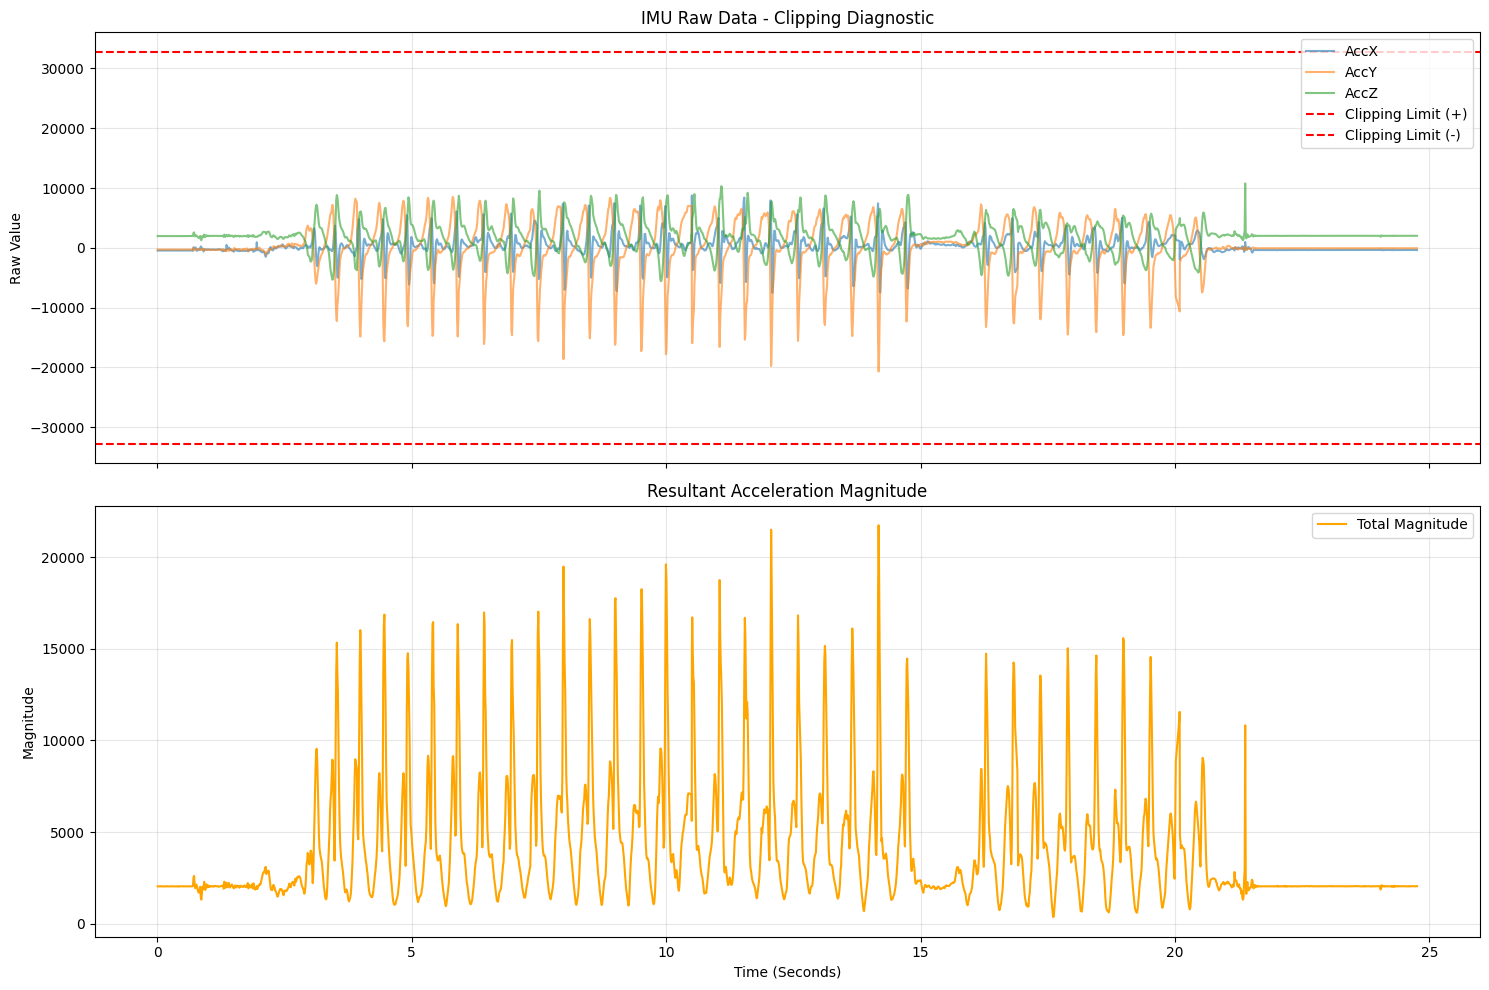

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load file CSV của Giang
file_name = "aikido_data_1776251754.csv" # Thay bằng tên file mới nhất của cậu
df = pd.read_csv(file_name)

# Kiểm tra nếu file có dữ liệu
if df.empty:
    print("Opps! File vẫn đang trống, Giang hãy đấm thử vài phát rồi lưu lại nhé!")
else:
    # 2. Tính Magnitude
    df['Acc_Mag'] = np.sqrt(df['AccX']**2 + df['AccY']**2 + df['AccZ']**2)

    # 3. Vẽ đồ thị
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

    # Plot 1: Các trục gia tốc lẻ & Đường giới hạn Clipping
    ax1.plot(df['Timestamp'], df['AccX'], label='AccX', alpha=0.6)
    ax1.plot(df['Timestamp'], df['AccY'], label='AccY', alpha=0.6)
    ax1.plot(df['Timestamp'], df['AccZ'], label='AccZ', alpha=0.6)
    
    # Kẻ đường giới hạn Clipping (32767)
    ax1.axhline(y=32767, color='r', linestyle='--', label='Clipping Limit (+)')
    ax1.axhline(y=-32768, color='r', linestyle='--', label='Clipping Limit (-)')
    
    ax1.set_title("IMU Raw Data - Clipping Diagnostic")
    ax1.set_ylabel("Raw Value")
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    # Plot 2: Magnitude (Độ mạnh tổng thể của cú đấm)
    ax2.plot(df['Timestamp'], df['Acc_Mag'], color='orange', label='Total Magnitude')
    ax2.set_title("Resultant Acceleration Magnitude")
    ax2.set_ylabel("Magnitude")
    ax2.set_xlabel("Time (Seconds)")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

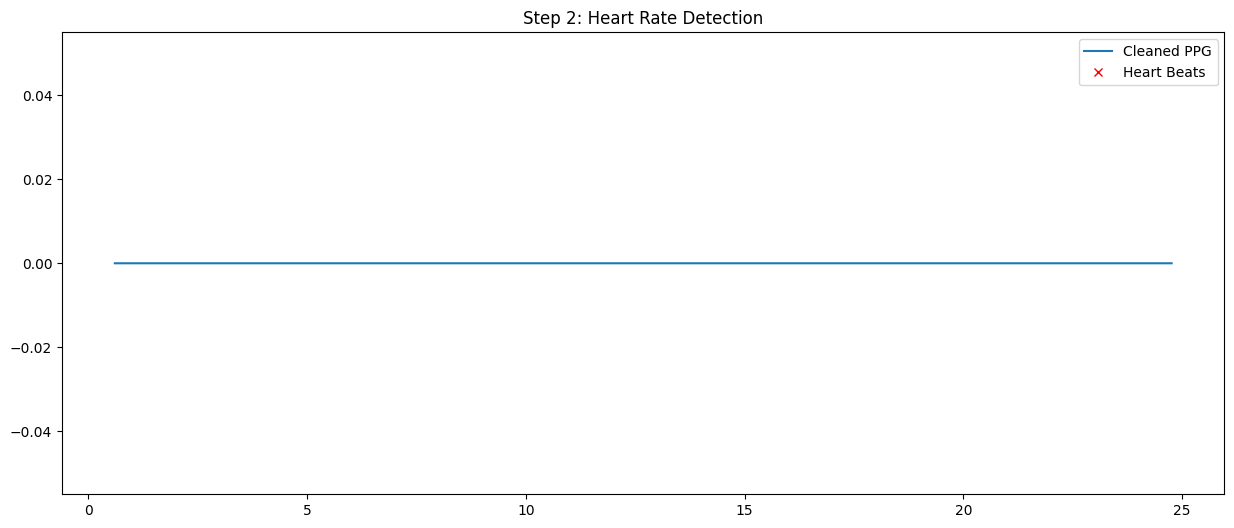

In [3]:
# import pandas as pd
# import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# 1. Load data
# df = pd.read_csv("tên_file_csv_của_cậu.csv")

# 2. Lọc đơn giản (Moving Average)
df['PPG_Smooth'] = df['Heart_IR'].rolling(window=5).mean()
# Khử Baseline Wander (Trừ đi trung bình trượt dải rộng)
df['PPG_Final'] = df['PPG_Smooth'] - df['PPG_Smooth'].rolling(window=50).mean()

# 3. Tìm đỉnh nhịp tim (Peak Detection)
# distance=50 nghĩa là các đỉnh cách nhau ít nhất 50 mẫu (với fs=100Hz là 0.5s)
peaks, _ = find_peaks(df['PPG_Final'], distance=50, prominence=100)

# 4. Vẽ kết quả
plt.figure(figsize=(15, 6))
plt.plot(df['Timestamp'], df['PPG_Final'], label='Cleaned PPG')
plt.plot(df['Timestamp'].iloc[peaks], df['PPG_Final'].iloc[peaks], "x", color='red', label='Heart Beats')
plt.title("Step 2: Heart Rate Detection")
plt.legend()
plt.show()

# Tính BPM trung bình
if len(peaks) > 1:
    duration = df['Timestamp'].iloc[peaks[-1]] - df['Timestamp'].iloc[peaks[0]]
    bpm = (len(peaks) - 1) / duration * 60
    print(f"Nhịp tim trung bình ước tính: {bpm:.1f} BPM")

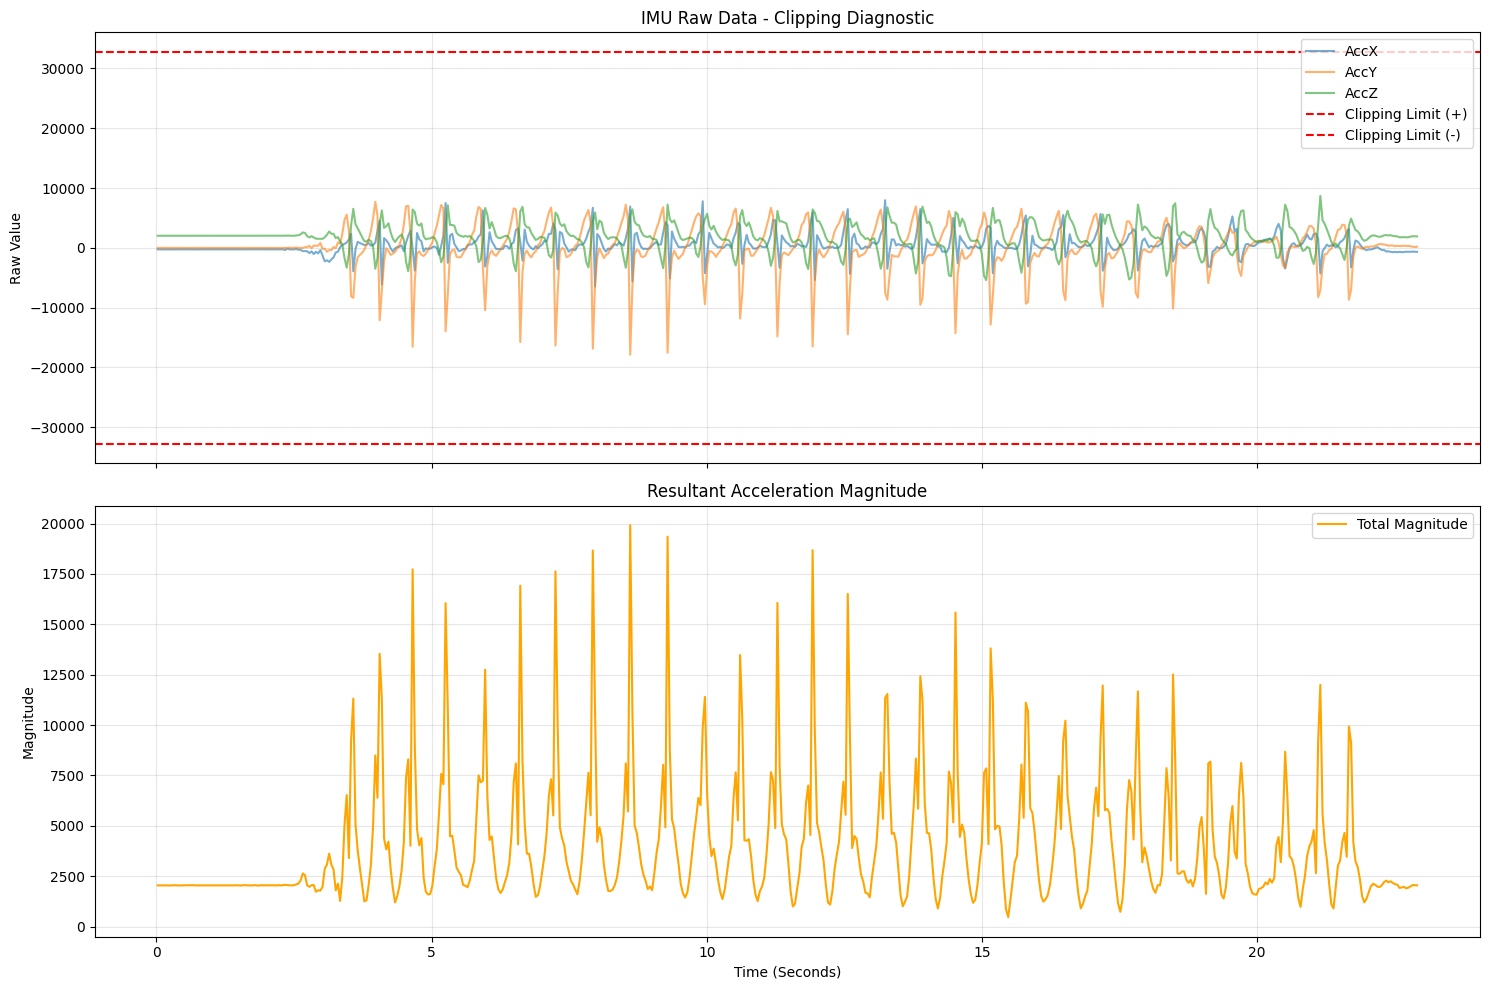

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load file CSV của Giang
file_name = "aikido_data_1776265276.csv" # Thay bằng tên file mới nhất của cậu
df = pd.read_csv(file_name)

# Kiểm tra nếu file có dữ liệu
if df.empty:
    print("Opps! File vẫn đang trống, Giang hãy đấm thử vài phát rồi lưu lại nhé!")
else:
    # 2. Tính Magnitude
    df['Acc_Mag'] = np.sqrt(df['AccX']**2 + df['AccY']**2 + df['AccZ']**2)

    # 3. Vẽ đồ thị
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

    # Plot 1: Các trục gia tốc lẻ & Đường giới hạn Clipping
    ax1.plot(df['Timestamp'], df['AccX'], label='AccX', alpha=0.6)
    ax1.plot(df['Timestamp'], df['AccY'], label='AccY', alpha=0.6)
    ax1.plot(df['Timestamp'], df['AccZ'], label='AccZ', alpha=0.6)
    
    # Kẻ đường giới hạn Clipping (32767)
    ax1.axhline(y=32767, color='r', linestyle='--', label='Clipping Limit (+)')
    ax1.axhline(y=-32768, color='r', linestyle='--', label='Clipping Limit (-)')
    
    ax1.set_title("IMU Raw Data - Clipping Diagnostic")
    ax1.set_ylabel("Raw Value")
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    # Plot 2: Magnitude (Độ mạnh tổng thể của cú đấm)
    ax2.plot(df['Timestamp'], df['Acc_Mag'], color='orange', label='Total Magnitude')
    ax2.set_title("Resultant Acceleration Magnitude")
    ax2.set_ylabel("Magnitude")
    ax2.set_xlabel("Time (Seconds)")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [4]:
import serial
import csv
import time

# --- Cấu hình kết nối ---
# Cậu lưu ý kiểm tra đúng cổng COM trong Device Manager hoặc PlatformIO Port list
SERIAL_PORT = 'COM4' 
BAUD_RATE = 115200
FILENAME = r"C:\Users\Admin\Downloads\draft_one_signal_final_project\src\aikido_data_1776265276.csv"
def collect():
    try:
        # Khởi tạo kết nối Serial với timeout để tránh treo chương trình
        ser = serial.Serial(SERIAL_PORT, BAUD_RATE, timeout=0.1)
        print(f"Đã kết nối thành công với {SERIAL_PORT}")
        print(f"Đang ghi dữ liệu vào file: {FILENAME}")
        print("Mẹo: Nhấn Ctrl+C để dừng thu thập dữ liệu.")
        
        with open(FILENAME, mode='w', newline='') as f:
            # Định nghĩa các cột dữ liệu (gồm Timestamp, IMU và PPG)
            fieldnames = ["Timestamp", "AccX", "AccY", "AccZ", "Heart_IR"]
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            
            data_row = {} # Dictionary để tập hợp các thành phần của một mẫu dữ liệu
            start_time = time.time()
            max_acc = 0
            
            # Danh sách các key bắt buộc phải nhận đủ trước khi ghi một dòng xuống CSV
            required_keys = ["AccX", "AccY", "AccZ", "Heart_IR"]

            while True:
                if ser.in_waiting > 0:
                    try:
                        # Đọc dòng và bỏ qua các lỗi giải mã do nhiễu vật lý
                        line = ser.readline().decode('utf-8', errors='ignore').strip()
                        
                        # Xử lý format ">Key:Value"
                        if line.startswith(">"):
                            parts = line[1:].split(":")
                            if len(parts) == 2:
                                key, val = parts[0], parts[1]
                                data_row[key] = val
                                
                                # Theo dõi gia tốc thô lớn nhất để kiểm tra độ nhạy cảm biến
                                if "Acc" in key:
                                    try:
                                        max_acc = max(max_acc, abs(int(val)))
                                    except ValueError:
                                        pass
                                        
                    except Exception as e:
                        print(f"Lỗi đọc Serial: {e}")

                    # --- LOGIC ĐỒNG BỘ HÓA ---
                    # Chỉ ghi vào CSV khi đã thu thập đủ bộ 4 thông số từ ESP32 gửi sang
                    if all(k in data_row for k in required_keys):
                        # Tính thời gian tương đối kể từ lúc bắt đầu
                        data_row["Timestamp"] = time.time() - start_time
                        writer.writerow(data_row)
                        
                        # Hiển thị phản hồi real-time trên terminal
                        ir_val = data_row.get("Heart_IR", 0)
                        print(f"Time: {data_row['Timestamp']:.2f}s | IR: {ir_val} | Max Acc: {max_acc}  ", end='\r')
                        
                        # Quan trọng: Reset bộ đệm để chờ bộ dữ liệu tiếp theo
                        data_row = {} 

    except serial.SerialException:
        print(f"\nLỖI: Không thể mở cổng {SERIAL_PORT}.")
        print("Hãy chắc chắn rằng cậu đã đóng Serial Monitor trong VSCode trước khi chạy script này.")
    except KeyboardInterrupt:
        print(f"\n\nĐã dừng thu thập. Dữ liệu đã lưu tại: {FILENAME}")
        print(f"Gia tốc thô lớn nhất ghi nhận được: {max_acc}")
    finally:
        if 'ser' in locals() and ser.is_open:
            ser.close()
            print("Đã đóng kết nối Serial.")

if __name__ == "__main__":
    collect()

Đã kết nối thành công với COM4
Đang ghi dữ liệu vào file: C:\Users\Admin\Downloads\draft_one_signal_final_project\src\aikido_data_1776265276.csv
Mẹo: Nhấn Ctrl+C để dừng thu thập dữ liệu.
Time: 46.24s | IR: 1094 | Max Acc: 32768    

Đã dừng thu thập. Dữ liệu đã lưu tại: C:\Users\Admin\Downloads\draft_one_signal_final_project\src\aikido_data_1776265276.csv
Gia tốc thô lớn nhất ghi nhận được: 32768
Đã đóng kết nối Serial.


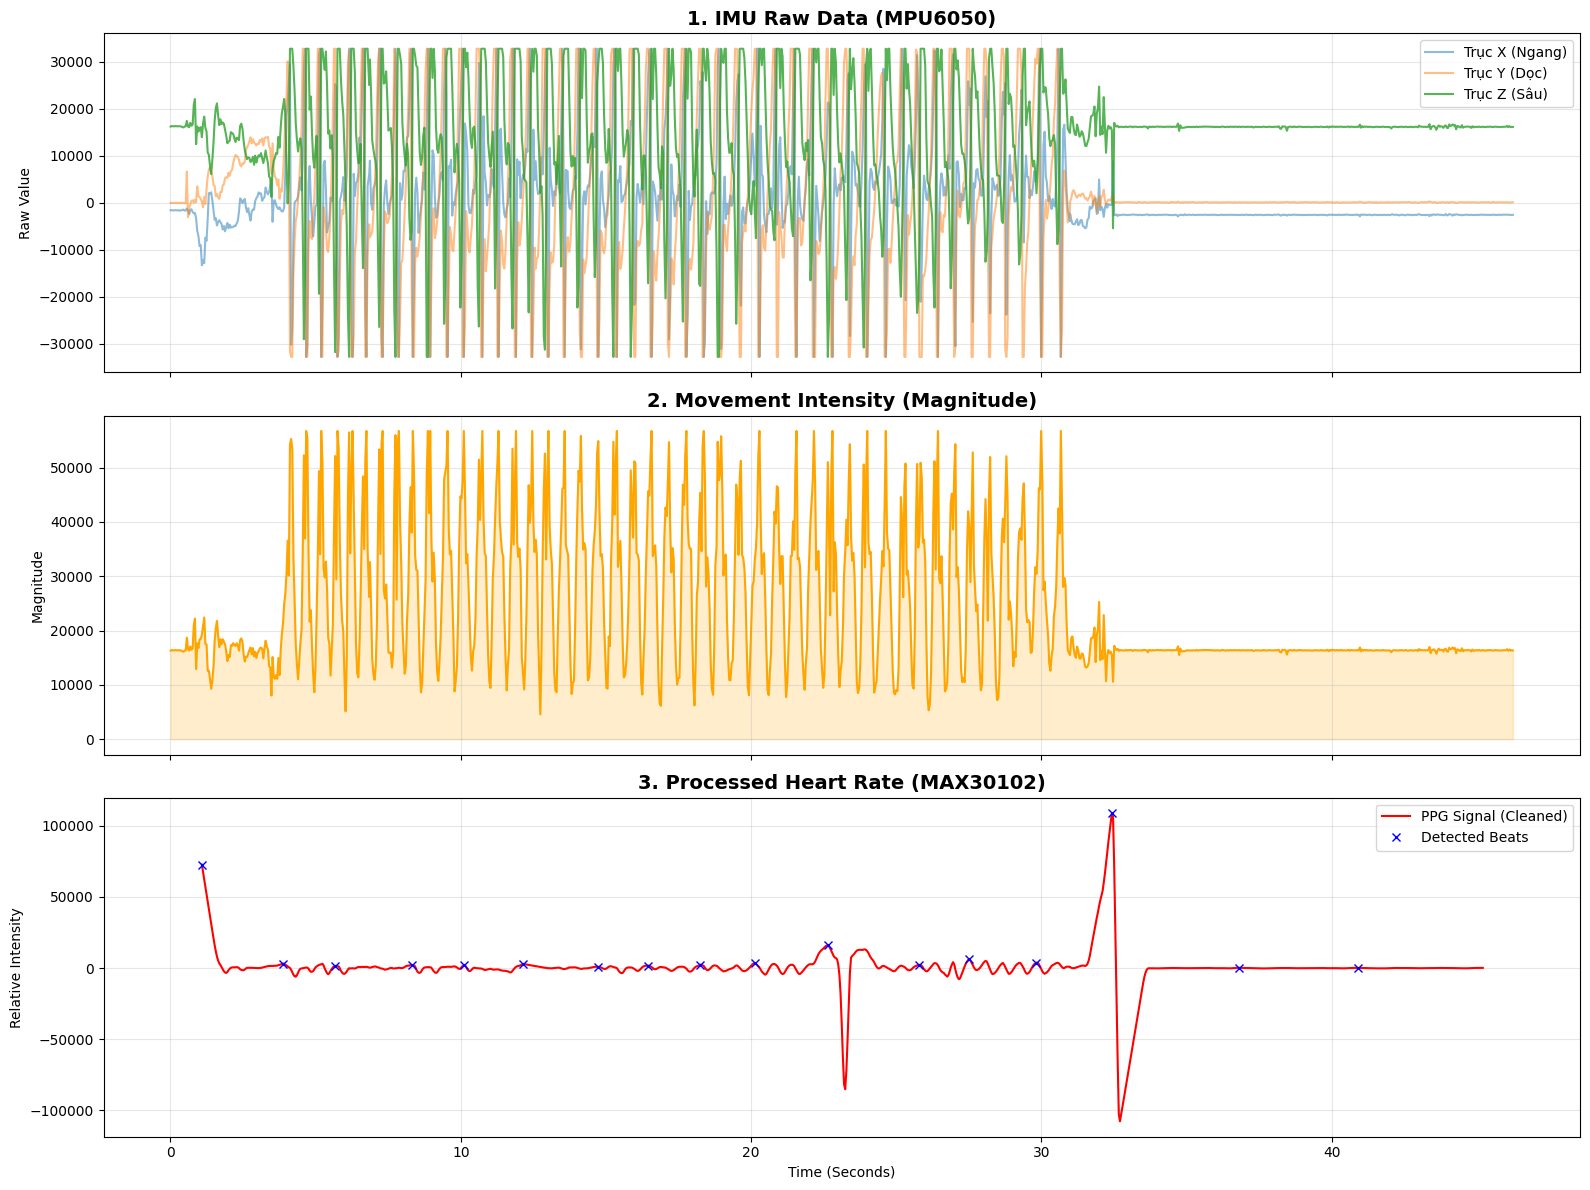

------------------------------
BÁO CÁO KẾT QUẢ TẬP LUYỆN
Thời gian thu thập: 46.24 giây
Số nhịp tim đếm được: 17
NHỊP TIM TRUNG BÌNH: 24.1 BPM
Cường độ vận động cao nhất (Raw): 56755
------------------------------


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# 1. ĐƯỜNG DẪN FILE (Thay bằng file mới nhất cậu vừa thu được)
file_path = r"C:\Users\Admin\Downloads\draft_one_signal_final_project\src\aikido_data_1776265276.csv"

# 2. ĐỌC VÀ TIỀN XỬ LÝ
df = pd.read_csv(file_path)

# Tính Magnitude (Độ mạnh tổng thể) - Giúp cậu thấy cường độ động tác Aikido
df['Acc_Mag'] = np.sqrt(df['AccX']**2 + df['AccY']**2 + df['AccZ']**2)

# Xử lý tín hiệu Tim (PPG)
# Bước A: Làm mượt (Lọc nhiễu tần số cao)
df['PPG_Smooth'] = df['Heart_IR'].rolling(window=5, center=True).mean()
# Bước B: Khử Baseline Wander (Trừ đi trung bình trượt dải rộng để tín hiệu nằm ngang)
df['PPG_Final'] = df['PPG_Smooth'] - df['PPG_Smooth'].rolling(window=50, center=True).mean()

# 3. TỰ ĐỘNG TÌM ĐỈNH NHỊP TIM
# distance=50 tương đương 0.5s (giả sử fs=100Hz), prominence là độ cao tối thiểu của đỉnh
peaks, _ = find_peaks(df['PPG_Final'].fillna(0), distance=40, prominence=200)

# 4. VẼ ĐỒ THỊ TỔNG HỢP
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Plot 1: Gia tốc 3 trục (Hướng của động tác)
ax1.plot(df['Timestamp'], df['AccX'], label='Trục X (Ngang)', alpha=0.5)
ax1.plot(df['Timestamp'], df['AccY'], label='Trục Y (Dọc)', alpha=0.5)
ax1.plot(df['Timestamp'], df['AccZ'], label='Trục Z (Sâu)', alpha=0.8)
ax1.set_title("1. IMU Raw Data (MPU6050)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Raw Value")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Plot 2: Magnitude (Độ mạnh của đòn thế)
ax2.plot(df['Timestamp'], df['Acc_Mag'], color='orange', label='Cường độ (Magnitude)')
ax2.fill_between(df['Timestamp'], df['Acc_Mag'], color='orange', alpha=0.2)
ax2.set_title("2. Movement Intensity (Magnitude)", fontsize=14, fontweight='bold')
ax2.set_ylabel("Magnitude")
ax2.grid(True, alpha=0.3)

# Plot 3: Nhịp tim đã qua xử lý
ax3.plot(df['Timestamp'], df['PPG_Final'], color='red', label='PPG Signal (Cleaned)')
ax3.plot(df['Timestamp'].iloc[peaks], df['PPG_Final'].iloc[peaks], "x", color='blue', label='Detected Beats')
ax3.set_title("3. Processed Heart Rate (MAX30102)", fontsize=14, fontweight='bold')
ax3.set_ylabel("Relative Intensity")
ax3.set_xlabel("Time (Seconds)")
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. TÍNH TOÁN KẾT QUẢ CUỐI CÙNG
if len(peaks) > 1:
    duration = df['Timestamp'].iloc[peaks[-1]] - df['Timestamp'].iloc[peaks[0]]
    bpm = (len(peaks) - 1) / duration * 60
    print("-" * 30)
    print(f"BÁO CÁO KẾT QUẢ TẬP LUYỆN")
    print(f"Thời gian thu thập: {df['Timestamp'].max():.2f} giây")
    print(f"Số nhịp tim đếm được: {len(peaks)}")
    print(f"NHỊP TIM TRUNG BÌNH: {bpm:.1f} BPM")
    print(f"Cường độ vận động cao nhất (Raw): {df['Acc_Mag'].max():.0f}")
    print("-" * 30)
else:
    print("Chưa đủ dữ liệu nhịp tim để tính BPM. Cậu thử ép chặt tay vào cảm biến hơn nhé!")

## CODE MỚI ##

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# --- TỰ ĐIỀN TÊN FILE CẬU VỪA THU ĐƯỢC Ở ĐÂY ---
file_path = r"C:\Users\Admin\Downloads\draft_one_signal_final_project\src\aikido_data_1776318285.csv"
df = pd.read_csv(file_path)

print("Cấu trúc dữ liệu:")
print(df.head())
print(f"\nTổng số mẫu: {len(df)}")

Cấu trúc dữ liệu:
   Timestamp  AccX  AccY   AccZ  Heart_IR
0   0.000844 -8256  4172 -12252         0
1   0.038885 -5108  2816 -13128    262143
2   0.078969 -4232  2544 -15228    262143
3   0.118885 -2396  1084 -15712    262143
4   0.159132 -4244 -2036 -18840    262143

Tổng số mẫu: 536


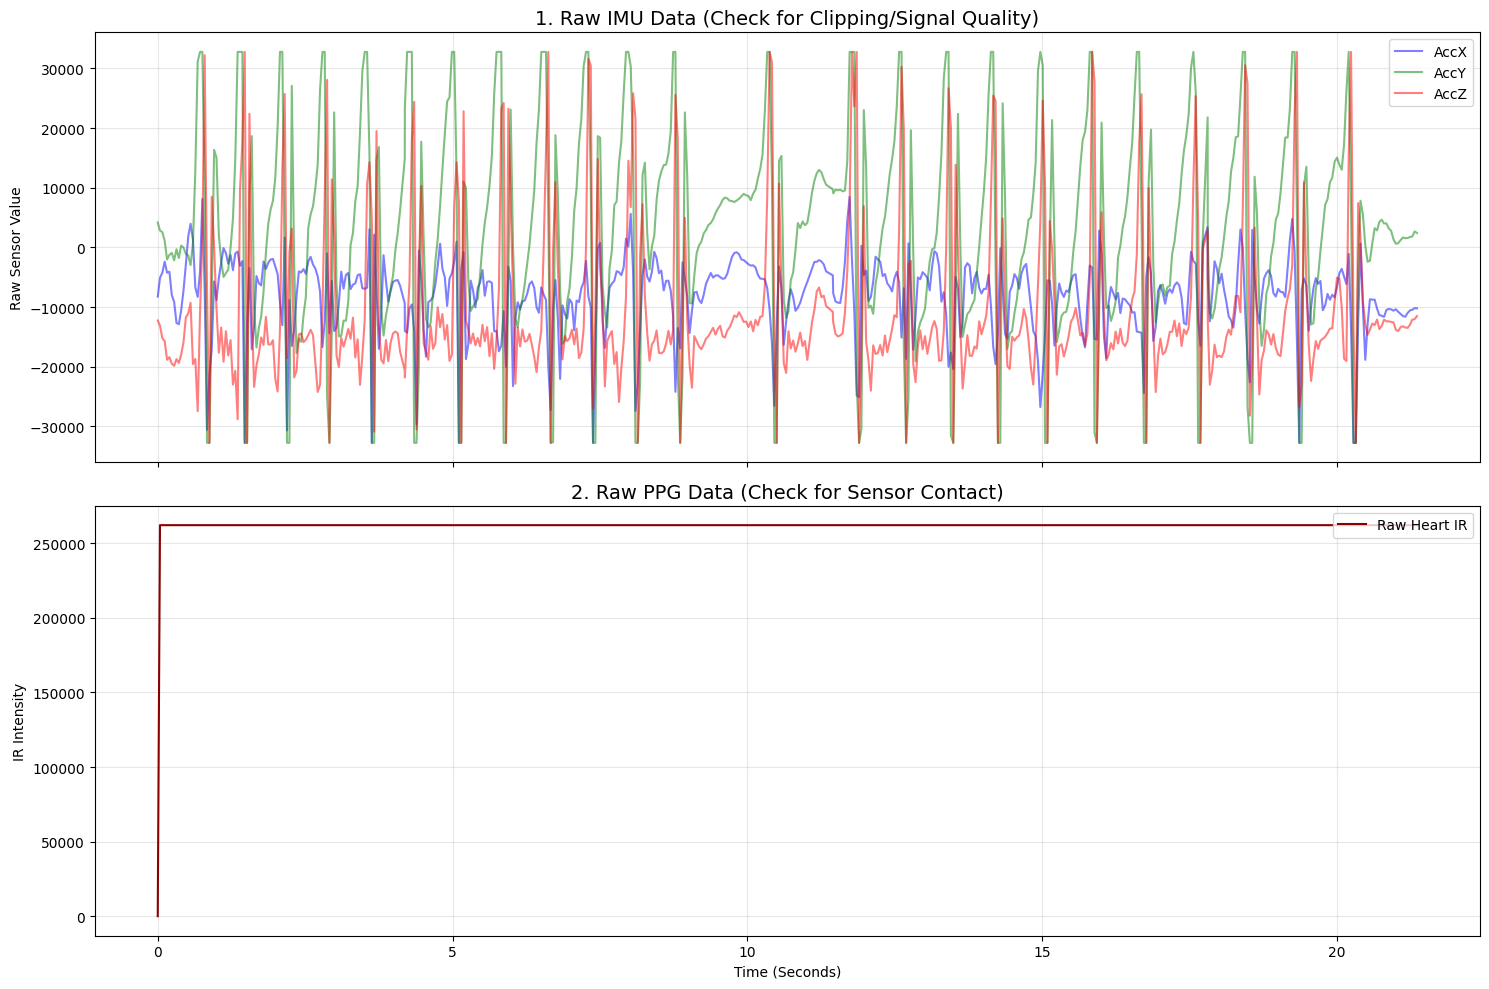

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# 1. Raw IMU (Gia tốc 3 trục)
ax1.plot(df['Timestamp'], df['AccX'], label='AccX', color='blue', alpha=0.5)
ax1.plot(df['Timestamp'], df['AccY'], label='AccY', color='green', alpha=0.5)
ax1.plot(df['Timestamp'], df['AccZ'], label='AccZ', color='red', alpha=0.5)
ax1.set_title("1. Raw IMU Data (Check for Clipping/Signal Quality)", fontsize=14)
ax1.set_ylabel("Raw Sensor Value")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# 2. Raw PPG (Dữ liệu tim thô)
ax2.plot(df['Timestamp'], df['Heart_IR'], color='darkred', label='Raw Heart IR')
ax2.set_title("2. Raw PPG Data (Check for Sensor Contact)", fontsize=14)
ax2.set_ylabel("IR Intensity")
ax2.set_xlabel("Time (Seconds)")
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

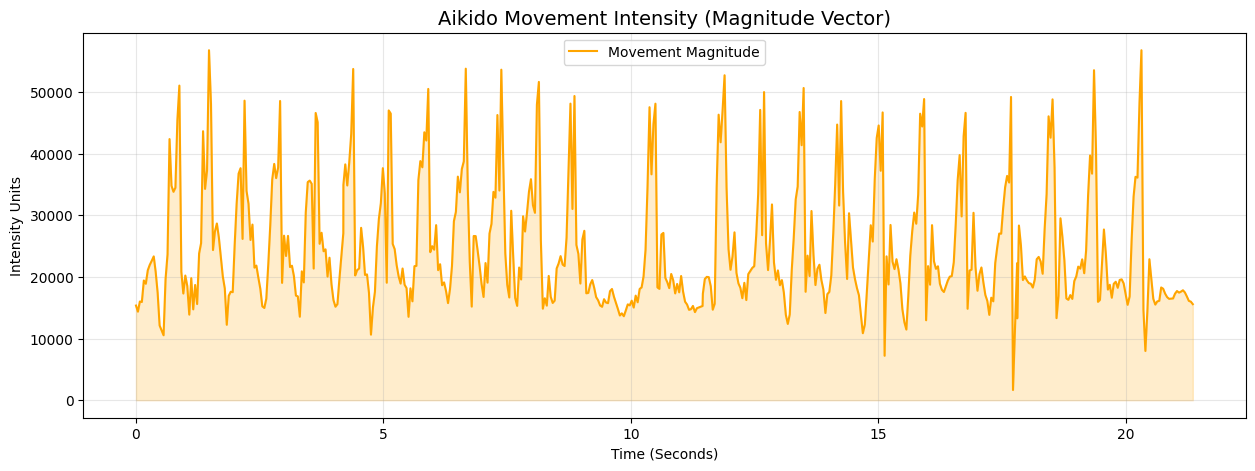

In [8]:
# Tính độ lớn vector gia tốc: sqrt(x^2 + y^2 + z^2)
df['Acc_Mag'] = np.sqrt(df['AccX']**2 + df['AccY']**2 + df['AccZ']**2)

plt.figure(figsize=(15, 5))
plt.plot(df['Timestamp'], df['Acc_Mag'], color='orange', label='Movement Magnitude')
plt.fill_between(df['Timestamp'], df['Acc_Mag'], color='orange', alpha=0.2)

plt.title("Aikido Movement Intensity (Magnitude Vector)", fontsize=14)
plt.ylabel("Intensity Units")
plt.xlabel("Time (Seconds)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

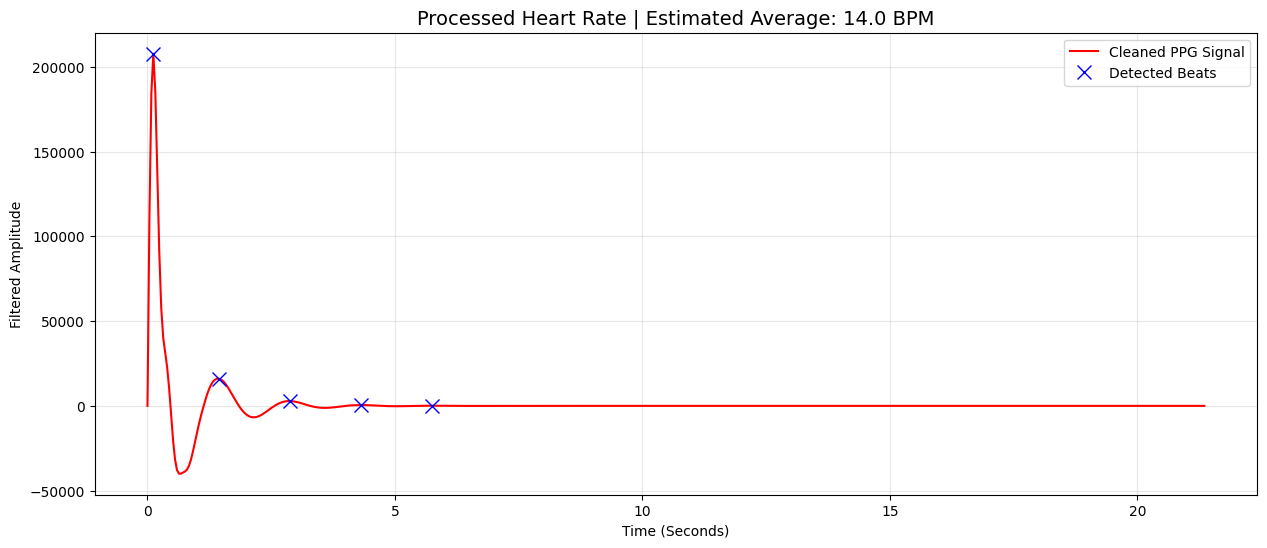

--- THỐNG KÊ TẬP LUYỆN ---
Thời gian tập: 21.35 s
Nhịp tim trung bình: 14.0 BPM
Cường độ vận động max: 56756


In [9]:
# 1. Thiết lập bộ lọc Bandpass (0.7Hz - 3.5Hz ~ 42BPM - 210BPM)
def butter_bandpass_filter(data, fs, lowcut=0.7, highcut=3.5, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

# 2. Tính tần số lấy mẫu (Sampling Frequency) thực tế
fs = 1 / df['Timestamp'].diff().mean()

# 3. Áp dụng lọc cho cột Heart_IR
df['PPG_Final'] = butter_bandpass_filter(df['Heart_IR'], fs)

# 4. Tìm đỉnh (Peak Detection)
# distance=fs*0.5 nghĩa là các nhịp cách nhau ít nhất 0.5s (max 120BPM)
# Cậu có thể giảm distance nếu tập cường độ cực cao
peaks, _ = find_peaks(df['PPG_Final'], distance=int(fs*0.5), prominence=100)

# 5. Vẽ đồ thị kết quả
plt.figure(figsize=(15, 6))
plt.plot(df['Timestamp'], df['PPG_Final'], color='red', label='Cleaned PPG Signal')
plt.plot(df['Timestamp'].iloc[peaks], df['PPG_Final'].iloc[peaks], "x", color='blue', markersize=10, label='Detected Beats')

# Tính BPM trung bình
duration = df['Timestamp'].max() - df['Timestamp'].min()
bpm = (len(peaks) / duration) * 60

plt.title(f"Processed Heart Rate | Estimated Average: {bpm:.1f} BPM", fontsize=14)
plt.ylabel("Filtered Amplitude")
plt.xlabel("Time (Seconds)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"--- THỐNG KÊ TẬP LUYỆN ---")
print(f"Thời gian tập: {duration:.2f} s")
print(f"Nhịp tim trung bình: {bpm:.1f} BPM")
print(f"Cường độ vận động max: {df['Acc_Mag'].max():.0f}")